# Modelo Estrutural de Negócios Bancários (K-Means Nativo)
Esta versão agrupa os bancos em cima de 7 índices financeiros chaves usando o K-Means Clássico no Scikit-Learn. O Mean-Centering foi utilizado para remover efeitos macroeconômicos (inflação/juros do ano) sem perder a importância (escala) das grandes contas contábeis no algoritmo de distância euclidiana.


In [1]:
import pandas as pd
import sqlite3
import numpy as np

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')
    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']
    query = f"SELECT {', '.join(financial_indicators)} FROM balancetes_media_ano WHERE cnpj IN (SELECT cnpj FROM balancetes_media_ano GROUP BY ano, cnpj);"
    df = pd.read_sql_query(query, conn)
    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']
    for col in colunas_para_limpar:
        df[col] = df[col].str.lower().str.normalize('NFD').str.replace(r'[\u0300-\u036f]', '', regex=True)

    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    
    df = df[~df['conta'].isin([88000008, 47100004, 51100007, 78100004, 61000001])]

    mapa_contas = df.groupby('conta')['nome_conta'].agg(lambda x: x.value_counts().index[0]).to_dict()
    novo_mapeamento = {}
    for conta, nome in mapa_contas.items():
        conta_str = str(conta)
        if conta_str.startswith('1'): novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'): novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'): novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'): novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'): novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'): novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'): novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'): novo_nome = f"compensacao passiva - {nome}"
        else: novo_nome = nome
        novo_mapeamento[conta] = novo_nome

    df = df.pivot(index=['ano', 'cnpj', 'nome', 'taxonomia'], columns='conta', values='saldo').reset_index()
    df['ano'] = df['ano'].astype(int)
    df = df[df[16000001] > 1000000]

    taxonomias_excluir = [
        'banco nacional de desenvolvimento economico social', 'bancos de desenvolvimento', 'agencias de fomento ou de desenvolvimento',
        'cooperativas de credito', 'soc. corretora de titulos e valores mobiliarios', 'soc distribuidora de titulos e valores mobiliarios',
        'sociedades de credito imobiliario', 'sociedade de credito imobiliario', 'companhias hipotecarias', 'associacao de poupanca e emprestimos',
        'sociedade de credito ao microempreendedor'
    ]
    df = df[~df['taxonomia'].isin(taxonomias_excluir)]

    colunas_para_inverter = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia']]
    for col in colunas_para_inverter:
        if pd.notna(df[col].max()) and (df[col].max() <= 0) and (df[col].min() < 0):
            df[col] = df[col] * -1

    df.fillna(0, inplace=True)
    df_original = df.copy().rename(columns=novo_mapeamento)
    
    return df_original

df_original = dados_bancos()



In [2]:
def criar_indices_estruturais(df_orig):
    indices = df_orig[['ano', 'cnpj', 'nome', 'taxonomia']].copy()
    
    ativo_col = 39999993 if 39999993 in df_orig.columns else 'compensacao ativa - total geral do ativo'
    if ativo_col not in df_orig.columns:
        ativo_col = [c for c in df_orig.columns if 'ativo' in str(c) and 'total' in str(c)][0]
    ativo_total = df_orig[ativo_col]
    
    col_cred = [c for c in df_orig.columns if 'operacoes de credito' in str(c) and 'provisoes' not in str(c)]
    if col_cred: indices['idx_credito'] = df_orig[col_cred[0]] / ativo_total
    
    col_tes = [c for c in df_orig.columns if 'titulos e valores mobiliarios' in str(c) and 'ativo' in str(c)]
    if col_tes: indices['idx_tesouraria'] = df_orig[col_tes[0]] / ativo_total
        
    cols_liq = [c for c in df_orig.columns if 'disponibilidade' in str(c) or 'aplicacoes interfinanceiras de liquidez' in str(c)]
    indices['idx_liquidez'] = df_orig[cols_liq].sum(axis=1) / ativo_total
    
    cols_dep = [c for c in df_orig.columns if 'deposit' in str(c) and 'passivo' in str(c)]
    indices['idx_funding_varejo'] = df_orig[cols_dep].sum(axis=1) / ativo_total
    
    cols_serv = [c for c in df_orig.columns if 'resultado credor' in str(c) and ('servico' in str(c) or 'tarifa' in str(c))]
    indices['idx_servicos'] = df_orig[cols_serv].sum(axis=1) / ativo_total
    
    cols_pass = [c for c in df_orig.columns if 'passivo exigivel' in str(c)]
    passivo_total = df_orig[cols_pass].sum(axis=1)
    indices['idx_capitalizacao'] = 1 - (passivo_total / ativo_total)
    
    cols_prov = [c for c in df_orig.columns if 'provisoes para operacoes de credito' in str(c)]
    if cols_prov and col_cred:
        indices['idx_risco_credito'] = df_orig[cols_prov[0]].abs() / df_orig[col_cred[0]].replace(0, np.nan)
        indices['idx_risco_credito'] = indices['idx_risco_credito'].fillna(0)
        
    indices.fillna(0, inplace=True)
    return indices

df_indices = criar_indices_estruturais(df_original)



### Winsorização e Mean-Centering (Sem Z-score)


In [3]:
def preparar_dados_painel(df, coluna_tempo='ano', p_inf=0.01, p_sup=0.99):
    df_processado = df.copy()
    colunas_financeiras = [col for col in df_processado.columns if col.startswith('idx_')]

    for col in colunas_financeiras:
        # A: Winsorização
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: x.clip(lower=x.quantile(p_inf), upper=x.quantile(p_sup))
        )
        # B: Mean-Centering (Anula a inflação/macros do ano mantendo o peso absoluto no K-Means)
        df_processado[col] = df_processado.groupby(coluna_tempo)[col].transform(
            lambda x: x - x.mean()
        )
        
    df_processado = df_processado.fillna(0)
    return df_processado

X_raw = df_indices.copy()
X_raw['chave_r'] = X_raw['ano'].astype(str) + "_" + X_raw['cnpj'].astype(str)
X_raw = X_raw.set_index('chave_r')

X_scaled = preparar_dados_painel(X_raw)



### K-Means Classico e Silhouette Score


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

colunas_modelo = [col for col in X_scaled.columns if col.startswith('idx_')]
X_model = X_scaled[colunas_modelo].values

print("=== Otimização da Silhueta ===")
melhor_k = 3
melhor_score = -1

for k in range(3, 7):
    kmeans = KMeans(n_clusters=k, random_state=77, n_init=50)
    labels = kmeans.fit_predict(X_model)
    score = silhouette_score(X_model, labels)
    print(f"Clusters: {k} | Silhouette Score: {score:.4f}")
    
    if score > melhor_score:
        melhor_score = score
        melhor_k = k

print(f"\nO melhor número de clusters é: {melhor_k}")

# Rodando o modelo definitivo
kmeans_final = KMeans(n_clusters=melhor_k, random_state=77, n_init=100)
X_scaled['Cluster'] = kmeans_final.fit_predict(X_model)

# Copiando para a base crua para visualização
X_raw['Cluster'] = X_scaled['Cluster'].values



=== Otimização da Silhueta ===
Clusters: 3 | Silhouette Score: 0.3054
Clusters: 4 | Silhouette Score: 0.3395
Clusters: 5 | Silhouette Score: 0.2774
Clusters: 6 | Silhouette Score: 0.2884

O melhor número de clusters é: 4


### Resultados Visuais (PCA Estético e Boxplots)


=== Médias Percentuais por Cluster ===
conta    idx_credito  idx_tesouraria  idx_liquidez  idx_funding_varejo  \
Cluster                                                                  
0               5.83            3.77          4.93               12.52   
1              13.62            3.81          4.44               21.69   
2               8.46            3.88          4.08                6.05   
3              22.18            4.36          8.41               60.48   

conta    idx_servicos  idx_capitalizacao  idx_risco_credito  Quantidade  
Cluster                                                                  
0                0.42              47.73              82.37         213  
1                0.26              29.84               7.31        1166  
2                0.24              69.56               7.92        1023  
3                0.67             -15.62               7.25         358  


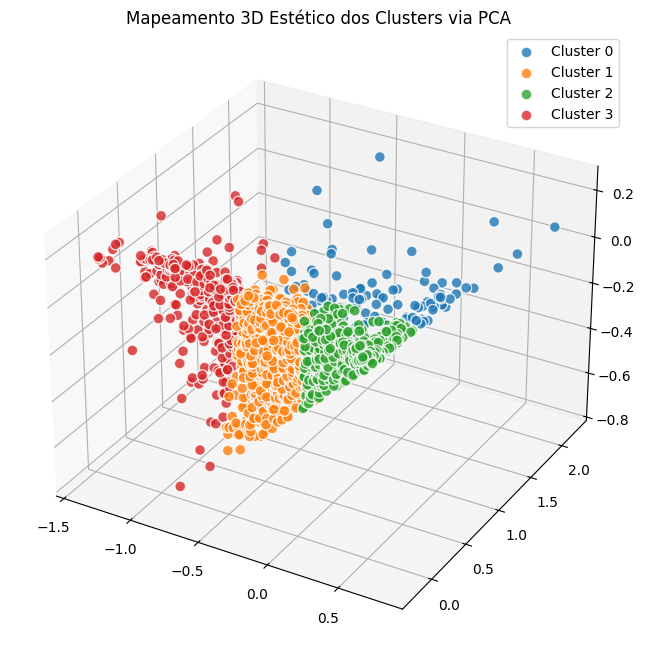

/tmp/ipykernel_130642/2789117599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=X_raw, ax=axes[i], palette='Set2')
/tmp/ipykernel_130642/2789117599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=X_raw, ax=axes[i], palette='Set2')
/tmp/ipykernel_130642/2789117599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=col, data=X_raw, ax=axes[i], palette='Set2')
/tmp/ipykernel_130642/2789117599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

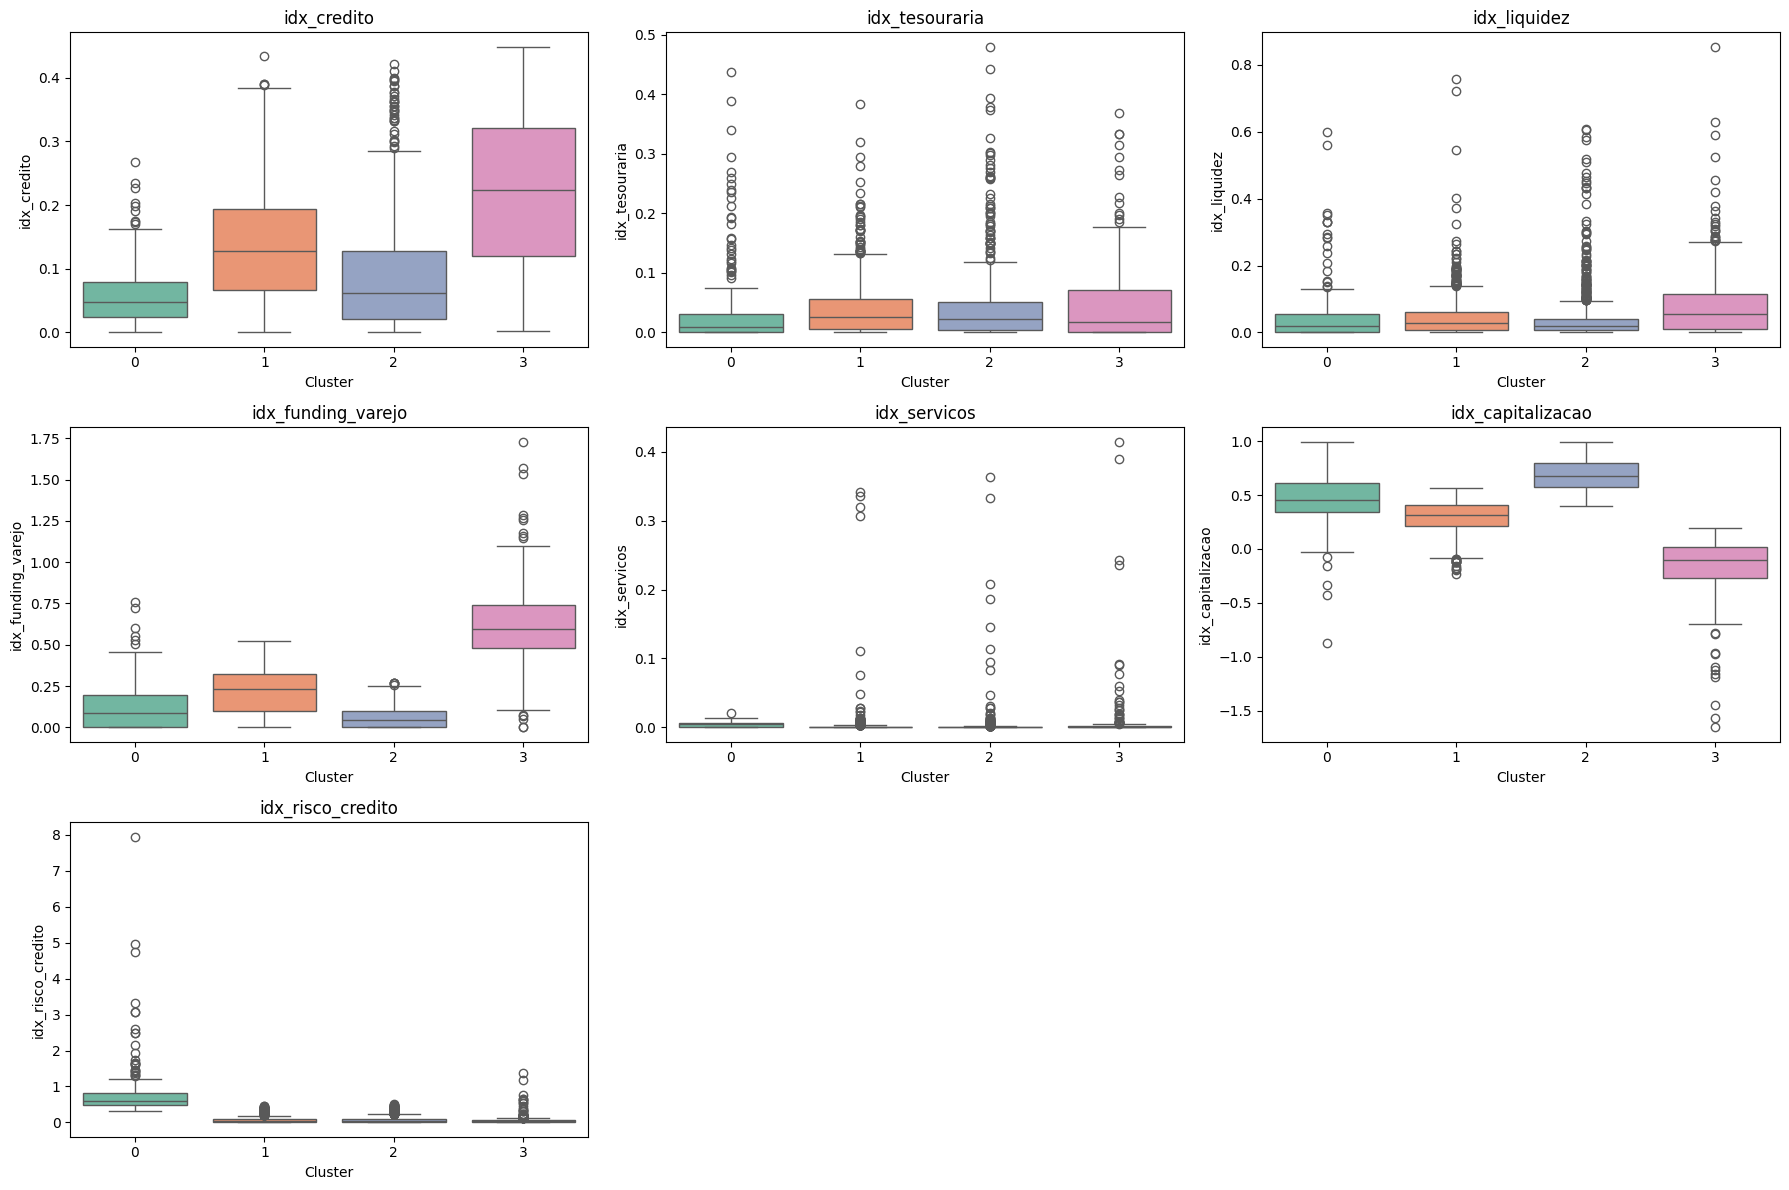

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Tabela de Médias (Em % reais da base original)
summary_table = (X_raw.groupby('Cluster')[colunas_modelo].mean() * 100).round(2)
summary_table['Quantidade'] = X_raw.groupby('Cluster').size()
print("=== Médias Percentuais por Cluster ===")
print(summary_table)

# 2. PCA apenas para jogar os 7 eixos em 3D e exibir visualmente
pca = PCA(n_components=3)
pca_coords = pca.fit_transform(X_model)
X_scaled['PCA_1'] = pca_coords[:, 0]
X_scaled['PCA_2'] = pca_coords[:, 1]
X_scaled['PCA_3'] = pca_coords[:, 2]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

X_scaled['Cluster'] = X_scaled['Cluster'].astype(str)
clusters = sorted(X_scaled['Cluster'].unique())
paleta = sns.color_palette('tab10', n_colors=len(clusters))

for i, c in enumerate(clusters):
    subset = X_scaled[X_scaled['Cluster'] == c]
    ax.scatter(subset['PCA_1'], subset['PCA_2'], subset['PCA_3'], 
               label=f'Cluster {c}', color=paleta[i], s=60, edgecolor='w', alpha=0.8)

ax.set_title('Mapeamento 3D Estético dos Clusters via PCA')
ax.legend()
plt.show()

# 3. Boxplots
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(colunas_modelo):
    sns.boxplot(x='Cluster', y=col, data=X_raw, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

